1] Import Libraries

In [1]:
#import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

2] Data Collection

In [2]:
#Create the data set
data ={
    "Study_Hours":[1,2,3,4,5,6,7,8,9,10],
    "Attendence":[60,85,70,95,65,80,90,75,88,72],
    "Marks":[32,42,47,58,61,67,76,79,88,91]
}
#Convert dict into dataframe
df=pd.DataFrame(data)
print(df)

   Study_Hours  Attendence  Marks
0            1          60     32
1            2          85     42
2            3          70     47
3            4          95     58
4            5          65     61
5            6          80     67
6            7          90     76
7            8          75     79
8            9          88     88
9           10          72     91


3] EDA and Preprocessing

In [3]:
print('First Five Rows:')
df.head()

First Five Rows:


,Study_Hours,Attendence,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61


In [4]:
print('Shape of Dataset:')
df.shape

Shape of Dataset:


(10, 3)

In [5]:
print('Information:')
df.info()

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  10 non-null     int64
 1   Attendence   10 non-null     int64
 2   Marks        10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


In [6]:
print('Stastistical Analysis:\n',df.describe())

Stastistical Analysis:
        Study_Hours  Attendence      Marks
count     10.00000   10.000000  10.000000
mean       5.50000   78.000000  64.100000
std        3.02765   11.489125  19.790289
min        1.00000   60.000000  32.000000
25%        3.25000   70.500000  49.750000
50%        5.50000   77.500000  64.000000
75%        7.75000   87.250000  78.250000
max       10.00000   95.000000  91.000000


In [7]:
print('Check for null values:')
df.isnull().sum()

Check for null values:


,0
Study_Hours,0
Attendence,0
Marks,0


In [8]:
#Duplicated Values
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates()

,Study_Hours,Attendence,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61
5,6,80,67
6,7,90,76
7,8,75,79
8,9,88,88
9,10,72,91


Data Visualization

Text(0.5, 1.0, 'Correlation Heatmap')

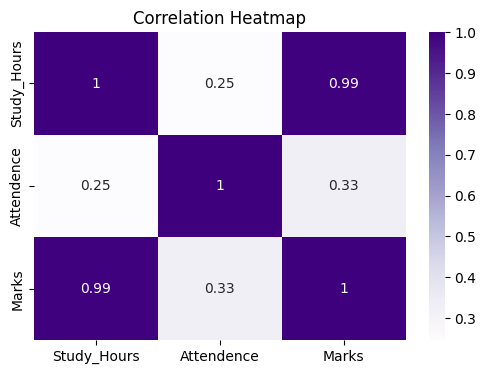

In [10]:
# Correlation Heatmap
import seaborn as sns
df_corr = df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(df_corr,annot=True , cmap='Purples')
plt.title('Correlation Heatmap')

A] Simple linear Regression by using sckit learn

In [11]:
# Feature Selection
x=df[['Study_Hours']]
y=df['Marks']

4] Model Building

In [12]:
# Split dataset into training and testing set
from sklearn.model_selection import train_test_split
x_train , x_test , y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=42)

In [13]:
x_test

,Study_Hours
8,9
1,2
5,6


In [14]:
# Import Model
from  sklearn.linear_model import LinearRegression
model = LinearRegression()
# Train the model
model.fit(x_train ,y_train)

LinearRegression()

In [15]:
# Predict the value
y_pred=model.predict(x_test)
y_pred

array([86.55445545, 41.22772277, 67.12871287])

In [16]:
# Print Equation
print('Intercept:',model.intercept_)
print('Slope:',model.coef_[0])

Intercept: 28.277227722772274
Slope: 6.475247524752477


5] Model Evalution

In [17]:
# Evaluation
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)

In [18]:
print('RSME:',round(rmse,3))
print('R2 Score',round(r2,2))

RSME: 0.949
R2 Score 1.0


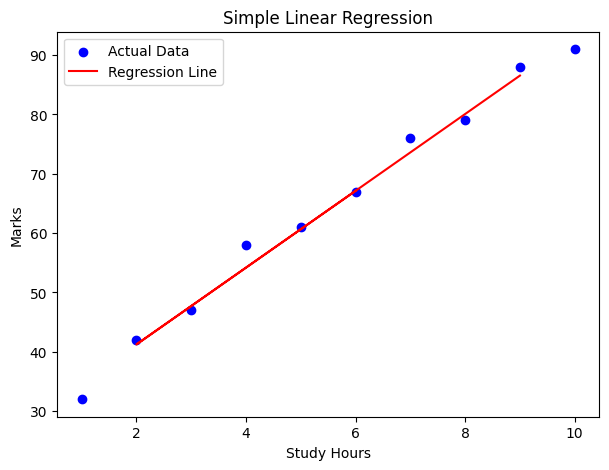

In [19]:
# Regression Line
plt.figure(figsize=(7,5))
plt.scatter(x,y,color='blue',label='Actual Data')
plt.plot(x_test, y_pred,
         color='red',
         label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

Residual plot

<function matplotlib.pyplot.show(close=None, block=None)>

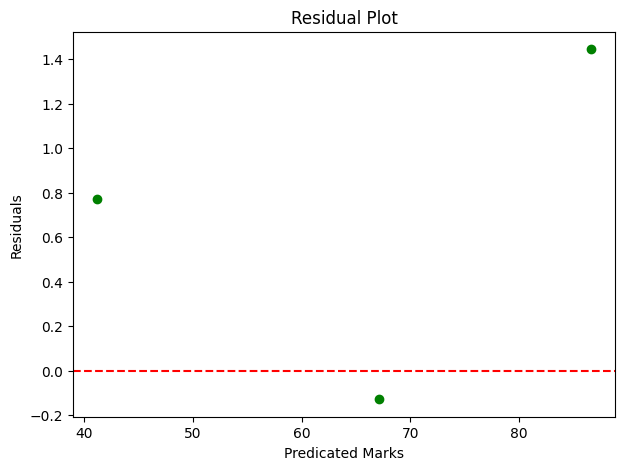

In [20]:
residuals=y_test-y_pred # Calculate Residual
plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals , color='green')
plt.axhline(y=0,
            color='red',
            linestyle='--')
plt.xlabel('Predicated Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show

B] Simple Linear Regression Using Numpy

In [21]:
# Independent Variable (Features)
x=df["Study_Hours"].values
# Dependent Variable(Target)
y=df["Marks"].values

In [22]:
#Calculate mean
x_mean = np.mean(x)
y_mean = np.mean(y)

In [23]:
# Calculate slope
m=np.sum((x-x_mean)*(y-y_mean))/np.sum((x-x_mean)**2)
#Calculate intercept
b=y_mean - m*x_mean
print("Slope=",m)
print("Intercept =",b)

Slope= 6.503030303030303
Intercept = 28.33333333333333


In [24]:
# Prediction
y_pred_numpy =m*x+b
y_pred_numpy

array([34.83636364, 41.33939394, 47.84242424, 54.34545455, 60.84848485,
       67.35151515, 73.85454545, 80.35757576, 86.86060606, 93.36363636])

Multiple Linear Regression

In [25]:
#Features Selection
x=df[['Study_Hours','Attendence']] #Independent Variables
y=df['Marks'] # Dependent Variable
# Split Dataset
x_train ,x_test, y_train,y_test=train_test_split(x,y,test_size=0.3, random_state=42)

Model Building

In [26]:
model =LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [27]:
# Prediction
y_pred = model.predict(x_test)
y_pred

array([88.08653885, 43.59718321, 67.84336712])

In [28]:
# Model Parameters
print('Intercept:',model.intercept_)
print("Coefficients",)
coeff=pd.DataFrame({
    'Feature': x.columns,
    'Coefficient':model.coef_
})
print(coeff)

Intercept: 16.14458419831481
Coefficients
       Feature  Coefficient
0  Study_Hours     6.280539
1   Attendence     0.175194


Model evalution

In [29]:
# Evaluation Metrics
print('Metircs Values of MLR:')
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)
print('RMSE:',round(rmse,2))
print('R2 Score:',round(r2,2))

Metircs Values of MLR:
RMSE: 1.04
R2 Score: 1.0


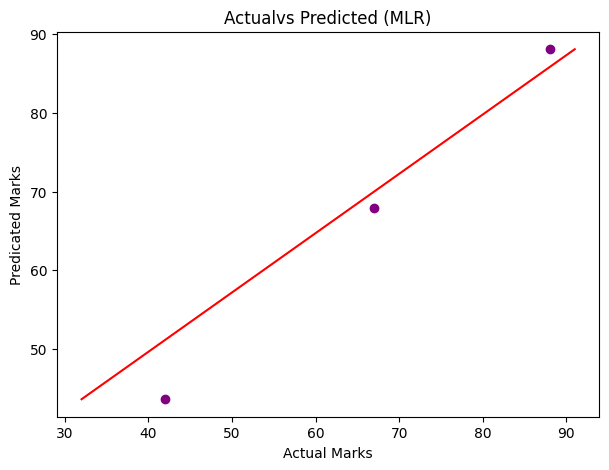

In [30]:
# Actual vs Predicated Plot
plt.figure(figsize=(7,5))
plt.scatter(y_test,y_pred,color='Purple')
# Perfect Prediction Line
plt.plot([y.min(),y.max()],
         [y_pred.min(),y_pred.max()],
         color='red')
plt.xlabel('Actual Marks')
plt.ylabel('Predicated Marks')
plt.title('Actualvs Predicted (MLR)')
plt.show()

Residual plot

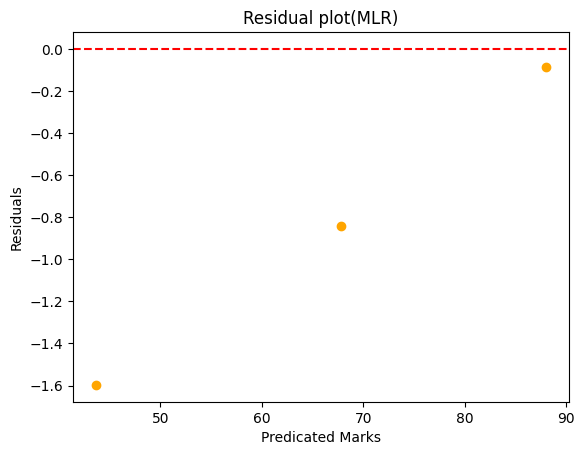

In [31]:
# calculate residual
residuals=y_test-y_pred
plt.scatter(y_pred,residuals,color='Orange')
plt.axhline(y=0,color='red',
            linestyle='--')
plt.xlabel('Predicated Marks')
plt.ylabel('Residuals')
plt.title('Residual plot(MLR)')
plt.show()